In [3]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from pydantic import BaseModel
class StockNewsItem(BaseModel):
    ticker: str
    company_name: str
    title: str
    content: str
    raw_content: str
    url: str
    published_date: str

In [6]:
from tavily import TavilyClient

tavily_client = TavilyClient();

def search_stock_news(ticker: str, company_name: str, max_results: int) -> list[StockNewsItem]:
    """return the most recent news limited by number"""
    
    query = f'{company_name} ({ticker}) latest financial news article'

    response = tavily_client.search(query=query, 
                                    topic="news", 
                                    max_results=max_results,
                                    search_depth="basic",
                                    include_raw_content="markdown",
                                    include_domains=["bloomberg.com","reuters.com","wsj.com","ft.com","cnbc.com","finance.yahoo.com"])
    
    results = [StockNewsItem(
        ticker=ticker,
        company_name=company_name,
        title=r['title'],
        content=r['content'],
        raw_content=r['raw_content'],
        url=r['url'],
        published_date=r['published_date']
    ) for r in response['results']]
   
    return results



In [7]:
# from IPython.display import display,Markdown


# for r in results:
#     md_content = f"""
# ### {r.company_name} ({r.ticker}) news 
                
# *{r.title}*
# <br><br>
# **Content:** {r.content}
# <br><br>
# **Raw Content:** {r.raw_content}
# <br><br>
# [{r.title}]({r.url})
# <br><br>
# """
#     display(Markdown(md_content))

In [8]:
#define a graph
from typing import List, Optional
from pydantic import BaseModel, Field

class NewsItems(BaseModel):
    title: str
    content: str
    content_kr: str
    raw_content: str
    summary: str
    summary_kr: str
    published_date: str
    url: str
    sentiment_label: str
    sentiment_score: float


class StockNewsState(BaseModel):
    ticker: str = Field(description="Ticker symbol. e.g. SNDK, APPL")
    company_name: Optional[str] = Field(default=None, description="The company name from the ticker symbol. e.g. Apple, inc.")
    news_items: Optional[List[NewsItems]] = Field(default_factory=list)


In [ ]:
from app.utils.financial import get_company_name

def load_news(state: StockNewsState):
    """Load news from data base if news exist; fill the state"""
    return {}

def route_messages(state: StockNewsState):
    """if there are news items in the state go to END; otherwise, go grab news!"""
    if(state.news_items):
        return 'end'
    return 'search_news'


def search_news(state: StockNewsState):
    """Search Top 3 news"""
    company_name = get_company_name(state.ticker)
    stock_news = search_stock_news(state.ticker, company_name, 3)

    news_items = [NewsItems(
            title=n.title,
            content=n.content,
            content_kr='',
            raw_content=n.raw_content,
            summary='',
            summary_kr='',
            published_date=n.published_date,
            url=n.url,
            sentiment_label='',
            sentiment_score=0.0
            ) for n in stock_news]                  
    
    return {"company_name": company_name, "news_items":news_items}


def save_to_db(state: StockNewsState):
    """Save the data to supadb"""
    return {}

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from app.utils.llm_models import get_llm
from pydantic import BaseModel, Field
from typing import List, Literal

class NewAnalysis(BaseModel):
    title: str = Field(description="news title")
    summary: str = Field(description="English Summary in 2-3 sentences")
    summary_kr: str = Field(description="Korean translation of the summary")
    content_kr: str = Field(description="Korean translation of the full content")
    sentiment_label: Literal["Positive", "Negative", "Neutral"] = Field(description="Sentiment analysis result - must of one of: 'Positive', 'Negative', 'Neutral'")
    sentiment_score: float = Field(description="")





def summarize_news(state: StockNewsState):
    """Summarize 3 news and add sentiment and embedding"""


    news_content = "\n\n".join([f"Article {i+1}: \nTitle: {n.title}\nContent: {n.raw_content}\nURL:{n.url}\nDate: {n.published_date}"
                                for i, n in enumerate(state.news_items)
                                ])  
    
    prompt = f"""
    You are a financial news analyst. Analyze the following news articles about {state.ticker} ({state.company_name})

    For each article, provide the following in JSON format:

    1. **summary**: A concise summary of the article in 2-3 sentences (English)
    2. **summary_kr**: Korean translation of the summary
    3. **content_kr**: Korean translation of the full content
    4. **sentiment_label**: Sentiment analysis result - must of one of: 'Positive', 'Negative', 'Neutral'
    5. **sentiment_score**: Sentiment confidence score between -1.0 (most negative) and 1.0 (most positive)

    News Articles:
    {news_content}

    Respond ONLY in the following JSON format, no extra text:
    [
        {{{{
            "title": "article title",
            "summary": "English summary here",
            "summary_kr": "한글 요약",
            "content_kr": "한글 번역",
            "sentiment_label": "Positive | Negative | Neutral",
            "sentiment_score": 0.0
        }}}},
    ...
    ]
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "You are a financial news analyst specializing in stock market analysis."),
        ("user", prompt)
    ])

      
    llm = get_llm()

    chain = prompt_template | llm

    response = chain.invoke({
        "ticker": state.ticker,
        "company_name": state.company_name,
        "news_content": news_content
    })



    print(response)
    return {}


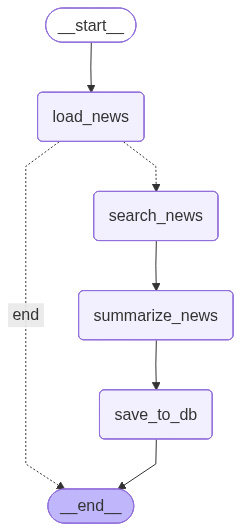

In [10]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder = StateGraph(StockNewsState)
builder.add_node("load_news", load_news)
#builder.add_node("route_messages", route_messages)
builder.add_node("search_news", search_news)
builder.add_node("summarize_news", summarize_news)
builder.add_node("save_to_db", save_to_db)

builder.add_edge(START, "load_news")
#builder.add_edge("load_news","route_messages")
#builder.add_conditional_edges("route_messages", route_messages, {"search_news": "search_news", "end": END})
builder.add_conditional_edges("load_news",route_messages,{"search_news": "search_news", "end":END})
builder.add_edge("search_news","summarize_news")
builder.add_edge("summarize_news", "save_to_db")
builder.add_edge("save_to_db", END)

stock_news_graph = builder.compile()

display(Image(stock_news_graph.get_graph(xray=1).draw_mermaid_png()))


In [11]:
result= stock_news_graph.invoke({"ticker": "SNDK", "company_name": ""})

content=[{'type': 'text', 'text': '[\n    {\n        "title": "Nvidia\'s Next AI Wave Sparks Big Calls on Micron, Dell, Arm Stocks",\n        "summary": "Mizuho Securities raised price targets for several tech companies, including Sandisk, citing increased demand for agentic artificial intelligence. The firm maintained an \'Outperform\' rating, highlighting strong growth prospects for memory demand in AI workloads.",\n        "summary_kr": "미즈호 증권은 에이전트형 인공지능(AI) 수요 증가를 이유로 샌디스크를 포함한 여러 기술 기업의 목표 주가를 상향 조정했습니다. 미즈호는 AI 워크로드에서의 메모리 수요에 대한 강력한 성장 전망을 강조하며 이들 기업에 대해 \'시장수익률 상회(Outperform)\' 등급을 유지했습니다.",\n        "content_kr": "미즈호 증권은 마이크론 테크놀로지, 샌디스크, 델 테크놀로지스, 암 홀딩스, 온 세미컨덕터의 목표 주가를 상향 조정했습니다. 이는 에이전트형 인공지능과 관련된 수요 증가에 따른 것입니다. 미즈호는 샌디스크의 목표 주가를 기존 1,625달러에서 1,825달러로 올렸으며, 5개 기업 모두에 대해 \'시장수익률 상회\' 등급을 유지했습니다. 미즈호는 AI 워크로드 확장에 따라 2027년까지 DRAM 수요가 지속적으로 강세를 보일 것으로 예상하며, 특히 AI 서버 배포 증가와 함께 고대역폭 메모리(HBM) 시장이 급격히 확대될 것으로 전망했습니다.",\n        "sentiment_label": "Positive",\n        "sentiment